# Stock Price Comparison — 2 Years
**Tickers:** SPY, BND, GLD, VTI, QQQ

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

tickers = ['SPY', 'BND', 'GLD', 'VTI', 'QQQ']

end_date   = datetime.today()
start_date = end_date - timedelta(days=2 * 365)

close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    close_df[ticker] = data['Close']

close_df.dropna(inplace=True)
print('Data loaded! Shape:', close_df.shape)
close_df.tail(3)

Data loaded! Shape: (501, 5)


,SPY,BND,GLD,VTI,QQQ
Date,,,,,
2026-03-26,645.090027,73.110001,400.640015,319.549988,573.789978
2026-03-27,634.090027,73.110001,414.700012,313.089996,562.580017
2026-03-30,631.969971,73.480003,414.579987,311.679993,558.280029


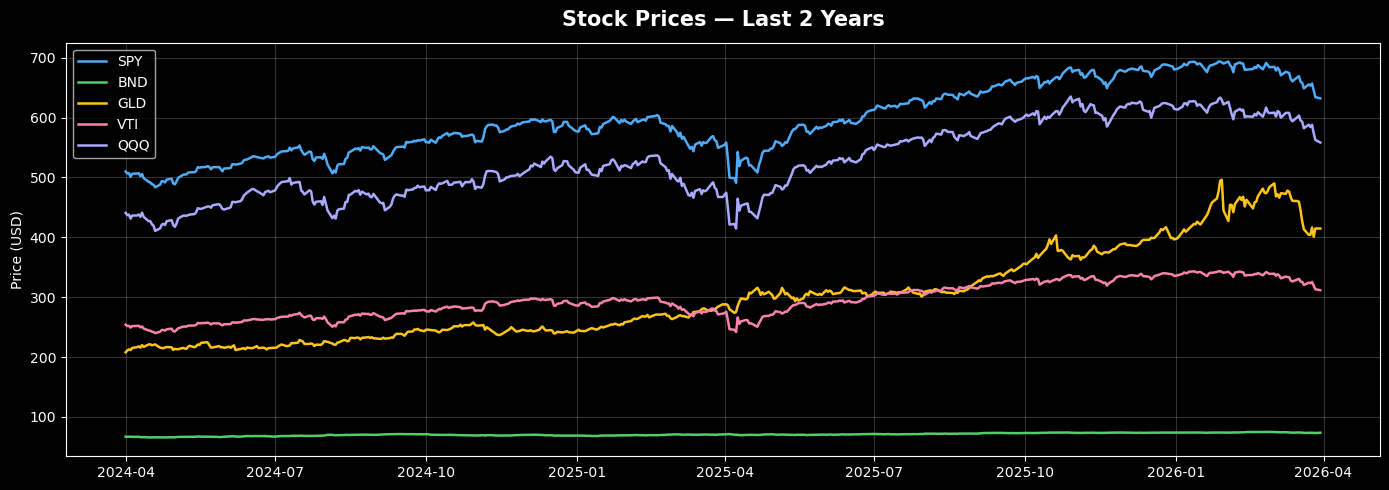

In [ ]:
# Stock Prices
colors = ['#4dabf7', '#51cf66', '#fcc419', '#f783ac', '#a9a9ff']

plt.figure(figsize=(14, 5))

for ticker, color in zip(tickers, colors):
    plt.plot(close_df.index, close_df[ticker], label=ticker, color=color, linewidth=1.8)

plt.title('Stock Prices (2 Years)', fontsize=15, fontweight='bold', pad=12)
plt.ylabel('Price (USD)')
plt.xlabel('')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Comparing Performance over time at Base

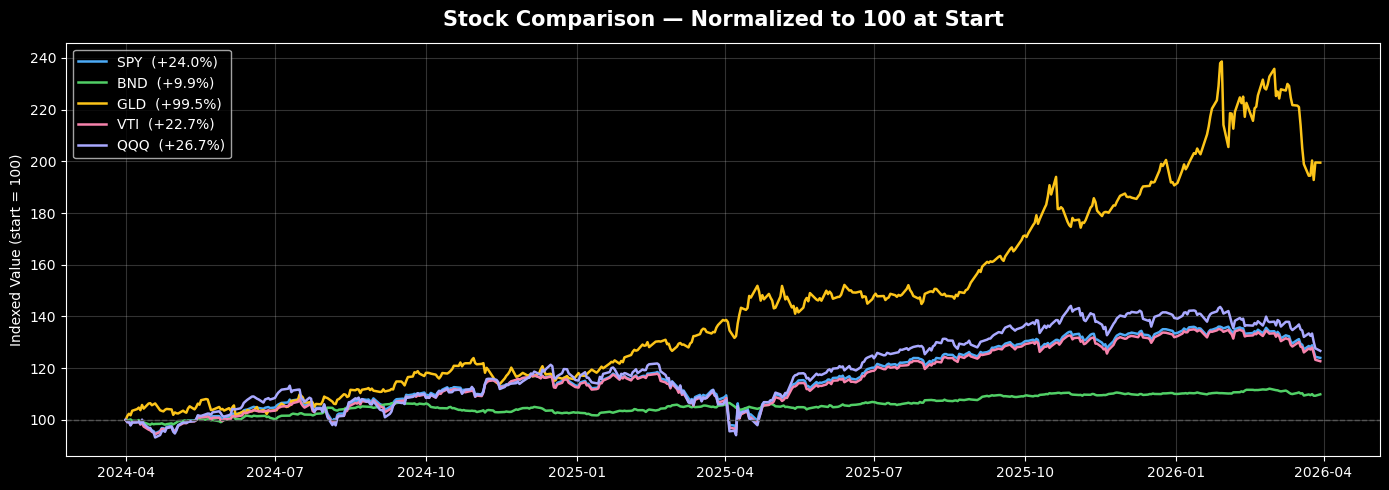

In [ ]:
norm_df = (close_df / close_df.iloc[0]) * 100

total_return = ((close_df.iloc[-1] - close_df.iloc[0]) / close_df.iloc[0] * 100).round(1)

plt.figure(figsize=(14, 5))
plt.style.use('dark_background')

for ticker, color in zip(tickers, colors):
    ret = total_return[ticker]
    plt.plot(norm_df.index, norm_df[ticker],
             label=f'{ticker}  ({ret:+.1f}%)', color=color, linewidth=1.8)

plt.axhline(100, color='#555555', linewidth=1, linestyle='--')
plt.title('Stock Comparison — Normalized to 100 at Start', fontsize=15, fontweight='bold', pad=12)
plt.ylabel('Indexed Value (start = 100)')
plt.xlabel('')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# Total % Return
print('\nReturns:')
for t in tickers:
    print(f' {t}: {total_return[t]:+.1f}%')


Returns:
 SPY: +24.0%
 BND: +9.9%
 GLD: +99.5%
 VTI: +22.7%
 QQQ: +26.7%
